In [1]:
import subprocess
import sys

#### If running on ROOT casa image some packages necessary for opening our files and plotting are not installed

def install_package(package_name):
    # Install the package using subprocess to call pip
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

def import_packages():
    try:
        import mplhep  # Replace with the module name of the package
    except ImportError:
        print(f"{'mplhep'} not found. Installing...")
        install_package("mplhep")
        import mplhep  # Import again after installation
    try:
        import hist  # Replace with the module name of the package
    except ImportError:
        print(f"{'hist'} not found. Installing...")
        install_package("hist")
        import hist  # Import again after installation
    try:
        import coffea  # Replace with the module name of the package
    except ImportError:
        print(f"{'coffea'} not found. Installing...")
        install_package("coffea==0.7.22")
        import coffea  # Import again after installation
        
        
import_packages()

mplhep not found. Installing...
  Using cached mplhep-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached mplhep_data-0.0.5-py3-none-any.whl.metadata (3.4 kB)
  Using cached uhi-1.0.0-py3-none-any.whl.metadata (5.7 kB)
Using cached mplhep-0.4.1-py3-none-any.whl (50 kB)
Using cached mplhep_data-0.0.5-py3-none-any.whl (9.1 MB)
Using cached uhi-1.0.0-py3-none-any.whl (25 kB)
hist not found. Installing...
  Using cached hist-2.9.1-py3-none-any.whl.metadata (16 kB)
  Using cached boost_histogram-1.6.1-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (26 kB)
  Using cached histoprint-2.6.0-py3-none-any.whl.metadata (17 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
Using cached hist-2.9.1-py3-none-any.whl (42 kB)
Using cached boost_histogram-1.6.1-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached histoprint-2.6.0-py3-none-any.whl (16 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
coffea not found. Installing...

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
#hep.style.use("CMS")
from matplotlib import colors, ticker
import pickle as pkl
from src.unfold.utils.integrate_and_rebin import *
from src.unfold.utils.merge_helpers import *

%load_ext autoreload

%autoreload 2

In [181]:
dijet = True
if dijet:
    with open('../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_MG__allUncALLRespOnly.pkl', "rb") as f:
        output_pythia= pkl.load( f )


    with open("../coffeaOutput/dijetHists_fixGenWeights_JetHT_allUncALLRespOnly.pkl", "rb") as f:
        output_data = pkl.load( f )
else:   
    with open('../coffeaOutput/trijet/trijetHists_fixGenWeights_QCD_MG_allUncALLRespOnly.pkl', "rb") as f:
        output_pythia= pkl.load( f )


    with open("../coffeaOutput/trijet/trijetHists_fixGenWeights_JetHT_allUncALLRespOnly.pkl", "rb") as f:
        output_data = pkl.load( f )
    
print(output_pythia['response_matrix_u'])

Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown', 'JERUp', 'JERDown', 'HEM', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown', 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up', 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_Relative

In [196]:


groomed = True
if not groomed:

    edges = [ 0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350, 400, 450, 500, 700, 900, 1100, 1300]
    edges_gen = [0, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 900, 1300]
if groomed:

    edges = [ 0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350, 400, 450, 500, 700, 900, 1100, 1300]
    edges_gen = [0, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 900, 1300]


if not groomed:
    resp_matrix_4d = output_pythia['response_matrix_u']

    input_data = output_data['ptreco_mreco_u']

    # fakes = output_pythia['fakes_u']
    # misses = output_miss['misses_u']
    # hist_bg = output_bg['response_matrix_u'].project('dataset','ptreco','mreco')
    # resp_matrix_pythia = resp_matrix_4d
    # resp_matrix_4d_herwig  = output_herwig['response_matrix_u'][{'systematic':['herwig']}]
    # fakes_herwig = output_herwig['fakes_u']
    # misses_herwig = output_herwig['misses_u']
else:
    resp_matrix_4d = output_pythia['response_matrix_g']

    input_data = output_data['ptreco_mreco_g']

    # fakes = output_pythia['fakes_g']
    # misses = output_miss['misses_g']
    # hist_bg = output_bg['response_matrix_u'].project('dataset','ptreco','mreco')
    # resp_matrix_pythia = resp_matrix_4d
    # resp_matrix_4d_herwig = output_herwig['response_matrix_g'][{'systematic':['herwig']}]
   
    # fakes_herwig = output_herwig['fakes_g']
    # misses_herwig = output_herwig['misses_g']

pt_edges = [0, 200, 290, 400, 480, 570, 680, 760, 820, 13000]
if dijet:
    pt_edges = [0, 200, 290, 400, 570, 680, 13000]
else:
    pt_edges = [0, 200, 290, 400, 570, 13000]
npt = len(pt_edges) - 1
nmreco = len(edges) -1
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptreco', pt_edges)
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptgen', pt_edges)

resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mreco',edges )

resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mgen',edges_gen )

input_data = rebin_hist(input_data, 'mreco', edges)
input_data = rebin_hist(input_data, 'ptreco', pt_edges)


resp_matrix_4d = resp_matrix_4d[{'syst':'nominal'}]

proj = resp_matrix_4d.project('mreco', 'ptreco','mgen', 'ptgen' )
M_np = proj.values(flow=False)
M_np_2d = M_np.reshape(M_np.shape[0]*M_np.shape[1],
                                 M_np.shape[2]*M_np.shape[3])
reco_proj = input_data.project('ptreco', 'mreco')
h2d = reco_proj.values()

# del output_pythia, resp_matrix_4d
# h_np = reco_proj.values(flow=False)        

In [197]:
print(M_np.shape)


(32, 6, 16, 6)


# Edit bins below 
(Only try with Ungroomed for now, groomed bin edges does not match with your file)

Axis permutation used (original->expected): (0, 1, 2, 3)
Axis permutation used (original->expected): (0, 1)
(reco pT 0, gen pT 0) nonzero bins: before=199, after=72
(reco pT 0, gen pT 1) nonzero bins: before=204, after=96
(reco pT 0, gen pT 2) nonzero bins: before=143, after=108
(reco pT 0, gen pT 3) nonzero bins: before=67, after=65
(reco pT 0, gen pT 4) nonzero bins: before=12, after=12
(reco pT 0, gen pT 5) nonzero bins: before=10, after=10
(reco pT 1, gen pT 0) nonzero bins: before=266, after=96
(reco pT 1, gen pT 1) nonzero bins: before=334, after=128
(reco pT 1, gen pT 2) nonzero bins: before=344, after=144
(reco pT 1, gen pT 3) nonzero bins: before=254, after=176
(reco pT 1, gen pT 4) nonzero bins: before=112, after=108
(reco pT 1, gen pT 5) nonzero bins: before=99, after=99
(reco pT 2, gen pT 0) nonzero bins: before=236, after=108
(reco pT 2, gen pT 1) nonzero bins: before=357, after=144
(reco pT 2, gen pT 2) nonzero bins: before=396, after=162
(reco pT 2, gen pT 3) nonzero bin

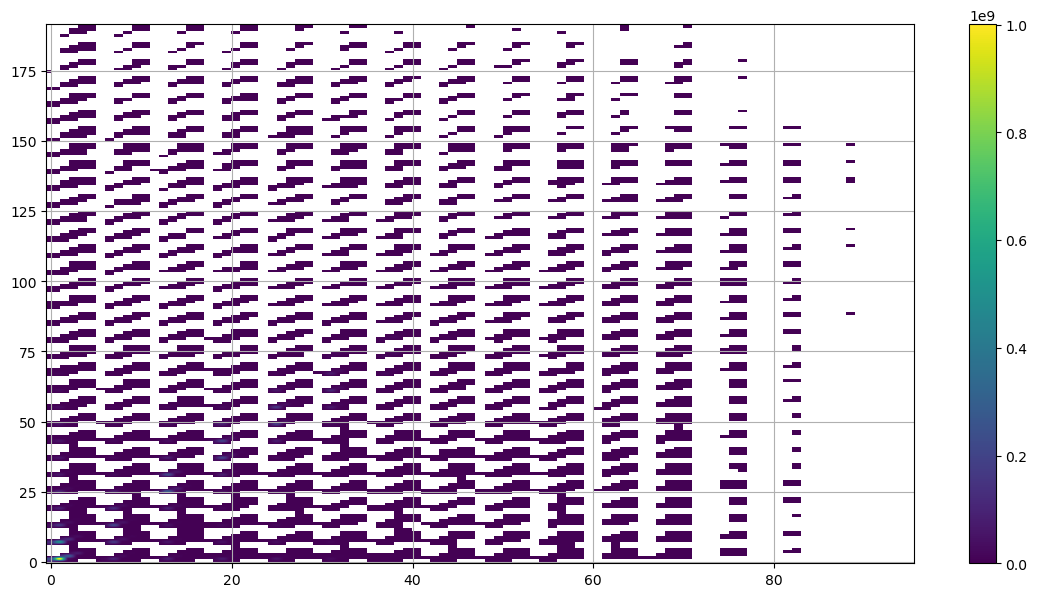

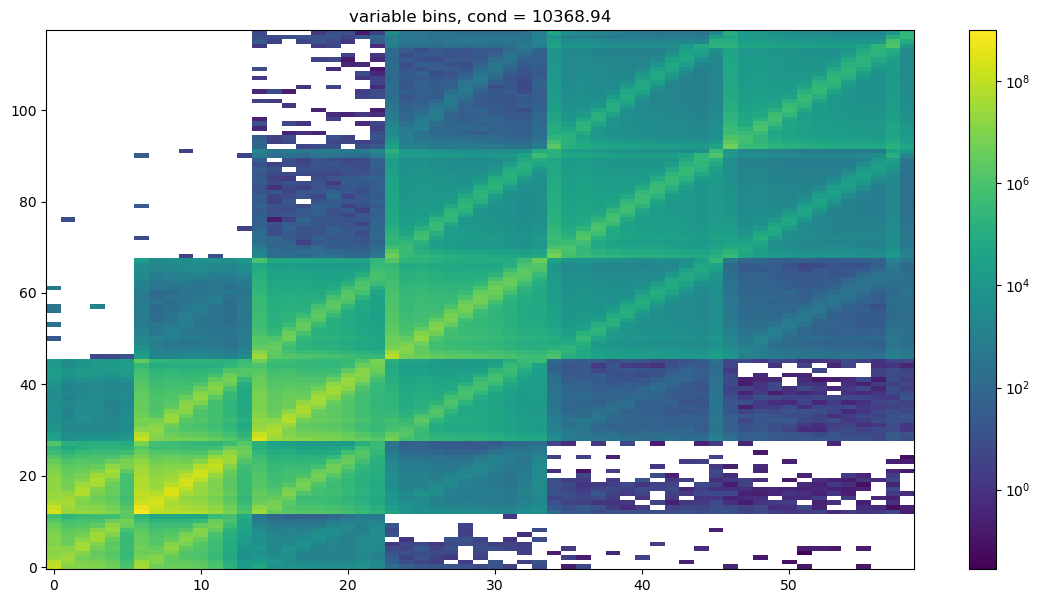

In [202]:


if not dijet:
    mass_edges_reco = [ 0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300,350, 400, 450, 500, 700, 900, 1100, 1300]
    mass_edges_gen = [0, 10, 20, 40, 60, 80, 100,120, 140, 160, 180, 200, 300, 400, 500, 900, 1300]
    if groomed:
        reco_mass_edges_by_pt = [[ 0,5,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 1300], #pt bin 1
                                 [ 0,5,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130,  1300], #pt bin 2
                                 [ 0,5,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 1300], #pt bin 3
                                 [ 0,5,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 1300],
                                 [ 0,5,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 140, 160, 180,200, 250, 300, 350,1300],
                                ]

        gen_mass_edges_by_pt = [[0,10, 20, 40, 60, 80, 100, 1300],
                                [0,10, 20, 40, 60, 80, 100, 120, 1300],
                                [0,10, 20, 40, 60, 80, 100, 120, 140, 160, 180,  1300],
                                [0,10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 1300],
                                [0,10, 20, 40, 60, 80, 100, 120, 160, 200, 300, 1300],
                               ]
    else:
        reco_mass_edges_by_pt = [[ 0,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 1300], #pt bin 1
                                 [ 0,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 1300], #pt bin 2
                                 [ 0,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 1300], #pt bin 3
                                 [ 0,10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 1300],
                                 [ 0,30,60, 70, 80, 90, 100, 110, 120, 130, 140, 150,160, 180, 200, 250, 300, 350, 1300],
                                ]

        gen_mass_edges_by_pt = [[0,20, 40, 60, 80, 100,1300],
                                [0,20, 40, 60, 80, 100,120, 140,  1300],
                                [0,20, 40, 60, 80, 100,120, 140, 160, 180, 1300],
                                [0,20, 40, 60, 80, 100,120, 140, 160, 180, 200, 1300],
                                [0,60, 80, 100, 120, 140, 160, 200, 300, 1300],
                               ]


else:
    mass_edges_reco = [ 0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350,400, 450, 500, 700, 900, 1100, 1300]
    mass_edges_gen = [0, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 900, 1300]
    if not groomed:
        reco_mass_edges_by_pt = [[ 0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 1300], 
                                 [ 0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 1300],#pt bin 1
                                 [ 0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150,160, 170, 1300], #pt bin 2
                                 [ 0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190,200,250, 1300], #pt bin 3
                                 [ 0,20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 1300],
                                 [ 0,20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350, 1300],
                                ]

        gen_mass_edges_by_pt = [[0, 20, 40, 60, 80, 100,1300],
                                [0, 20, 40, 60, 80, 100, 120, 1300],
                                [0, 20, 40, 60, 80, 100, 120, 140, 160, 1300],
                                [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 1300],
                                [0, 40, 60, 80, 100, 120, 140, 160, 180, 200, 1300],
                                [0, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 1300],
                               ]
    else:
        reco_mass_edges_by_pt = [[ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90,1300], 
                                 [ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130,  1300],#pt bin 1
                                 [ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 1300], #pt bin 2
                                 [ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 1300], #pt bin 3
                                 [ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 1300],
                                 [ 0,5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350, 1300],
                                ]

        gen_mass_edges_by_pt = [[0,10,20, 40, 60, 80,1300],
                                [0,10,20, 40, 60, 80, 100, 120, 1300],
                                [0,10,20, 40, 60, 80, 100, 120, 140, 1300],
                                [0,10,20, 40, 60, 80, 100, 120, 140, 160, 180, 1300],
                                [0,10,20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 1300],
                                [0,10,20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 1300],
                               ]



# Ensure correct axis order first:
H, perm_used = reorder_to_expected(M_np, edges, pt_edges, edges_gen)
print("Axis permutation used (original->expected):", perm_used)

h2d, perm_used = reorder_to_expected_2d(h2d, edges, pt_edges)
print("Axis permutation used (original->expected):", perm_used)
# Build the unpadded mosaic (no NaNs):
mosaic, blocks = mosaic_no_padding(
    H, mass_edges_reco, mass_edges_gen,
    reco_mass_edges_by_pt, gen_mass_edges_by_pt
)

mosaic_2d = merge_mass_flat(h2d,
                         mass_edges_reco,
                         reco_mass_edges_by_pt)

# ---- 4) Occupancy report: before vs after in each (pT_reco, pT_gen) block ----
n_rp = len(pt_edges) - 1
n_gp = len(pt_edges) - 1
for i in range(n_rp):
    for j in range(n_gp):
        before_block = H[:, i, :, j]
        after_block  = blocks[(i, j)]
        nz_before = np.count_nonzero(before_block)
        nz_after  = np.count_nonzero(after_block)
        print(f"(reco pT {i}, gen pT {j}) nonzero bins: before={nz_before}, after={nz_after}")

# Optional: plot without masking zeros so you can see exactly what's zero

# Before
fig, ax = plt.subplots(figsize=(14, 7))
masked = np.ma.masked_where(M_np_2d <= 0, M_np_2d)
im = ax.imshow(masked, origin="lower", aspect="auto")
#ax.set_title(f"Unpadded mosaic (all-ones)  |  max abs diff = {max_abs_diff:g}")
plt.colorbar(im, ax=ax)
plt.grid()
plt.show()
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(14, 7))
# im = ax.imshow(mosaic, origin="lower", aspect="auto")
# plt.colorbar(im, ax=ax); plt.show()

# If you *do* want to hide zeros, this masks only exact zeros (no NaNs present here):
masked = np.ma.masked_where(mosaic == 0, mosaic)
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(masked, origin="lower", aspect="auto", norm = 'log')
plt.title(f"variable bins, cond = {np.linalg.cond(mosaic):.2f}")

plt.colorbar(im, ax=ax, ); plt.show()




In [ ]:
import ROOT
import numpy as np

# ------------------------------------------------------------------
# 1.  Provide your numpy inputs
# ------------------------------------------------------------------
# resp_np   : 2-D numpy array – rows = reco bins, cols = true(gen) bins
# meas_flat : 1-D numpy array – reco distribution ( *same* row order as resp_np )

# example placeholders – replace with your real arrays
resp_np   = mosaic
meas_flat = mosaic_2d

n_reco, n_true = resp_np.shape
assert len(meas_flat) == n_reco, "measured spectrum must have n_reco bins"

# ------------------------------------------------------------------
# 2.  Build ROOT histograms
# ------------------------------------------------------------------
# Response matrix:  x = truth  (columns),  y = reco  (rows)
h_resp = ROOT.TH2D("resp", "response;truth bin;reco bin",
                   n_true,  0, n_true,
                   n_reco,  0, n_reco)
for i_reco in range(n_reco):
    for j_true in range(n_true):
        h_resp.SetBinContent(j_true + 1, i_reco + 1, resp_np[i_reco, j_true])

# Measured (reco) spectrum
h_meas = ROOT.TH1D("meas", "measured;reco bin;entries", n_reco, 0, n_reco)
for i_reco, val in enumerate(meas_flat, 1):
    h_meas.SetBinContent(i_reco, float(val))

# ------------------------------------------------------------------
# 3.  Run TUnfold
# ------------------------------------------------------------------
unfold = ROOT.TUnfoldDensity(
    h_resp,
    ROOT.TUnfold.kHistMapOutputHoriz  # orientation matches (truth x, reco y)
)

# feed measured spectrum
status = unfold.SetInput(h_meas)
if status >= 10000:
    raise RuntimeError("TUnfold input had overflow/underflow – check your hist.")

# Optional: scan L-curve to choose tau.  Quick-n-dirty: 20 points, auto range
#unfold.ScanSURE(50, 0.000000001, 0.1, )
#### Can't use scansure bc using root 6.26
nPoint, tauMin, tauMax = 30, 1e-6, 1e+0   # coarse example range
logTauX = ROOT.MakeNullPointer(ROOT.TSpline)
logTauY = ROOT.MakeNullPointer(ROOT.TSpline)
lCurve = ROOT.MakeNullPointer(ROOT.TGraph)

best_point = unfold.ScanLcurve(
    nPoint,
    tauMin,
    tauMax,
lCurve, logTauX, logTauY
)


# ------------------------------------------------------------------
# 4.  Grab the unfolded spectrum and covariance
# ------------------------------------------------------------------
h_unfold = unfold.GetOutput("unfold")          # TH1D with n_true bins
#cov      = unfold.GetEmatrixInput()            # TH2D covariance of input
#cov_out  = unfold.GetEmatrixOutput("cov_out")  # TH2D covariance of unfolded

# quick printout
h_unfold.Print("all")


TH1.Print Name  = unfold, Entries= 108, Total sum= 1.1155e+10
 fSumw[0]=0, x=-0.5, error=0
 fSumw[1]=7.3622e+08, x=0.5, error=7370.22
 fSumw[2]=7.07978e+08, x=1.5, error=7055.63
 fSumw[3]=6.79762e+08, x=2.5, error=6743.08
 fSumw[4]=6.51626e+08, x=3.5, error=6433.38
 fSumw[5]=6.2366e+08, x=4.5, error=6127.68
 fSumw[6]=5.95974e+08, x=5.5, error=5827.4
 fSumw[7]=5.68653e+08, x=6.5, error=5533.78
 fSumw[8]=5.4159e+08, x=7.5, error=5246.39
 fSumw[9]=5.14707e+08, x=8.5, error=4965.03
 fSumw[10]=4.8796e+08, x=9.5, error=4689.73
 fSumw[11]=4.61346e+08, x=10.5, error=4420.8
 fSumw[12]=4.34894e+08, x=11.5, error=4158.83
 fSumw[13]=4.08657e+08, x=12.5, error=3904.48
 fSumw[14]=3.82686e+08, x=13.5, error=3658.3
 fSumw[15]=3.56996e+08, x=14.5, error=3420.46
 fSumw[16]=3.31619e+08, x=15.5, error=3191.16
 fSumw[17]=3.06611e+08, x=16.5, error=2970.74
 fSumw[18]=2.8206e+08, x=17.5, error=2759.75
 fSumw[19]=2.58087e+08, x=18.5, error=2558.88
 fSumw[20]=2.34841e+08, x=19.5, error=2368.92
 fSumw[21]=2.124

Warning in <TROOT::Append>: Replacing existing TH1: resp (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: meas (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Info in <TUnfold::TUnfold>: underflow and overflow bin do not depend on the input data
Info in <TUnfold::TUnfold>: 106 input bins and 53 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0 (xaxis:truth bin[ufl])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #54 (xaxis:truth bin[ofl])
Info in <TUnfoldDensity::RegularizeOneDistribution>: regularizing xaxis regMode=3 densityMode=3 axisSteering=*[UOB]
Info in <TUnfoldDensity::InvertMSparseSymmPos>: cholesky-decomposition failed, try eigenvalue analysis
Warning in <TUnfoldDensity::DoUnfold>: rank of output covariance is 11 expect 53
Info in <TUnfoldDensity::ScanLcurve>: logtau=0.000000 X=10.563879 Y=7.843653
Info in <TUnfoldDensity::ScanLcurve>: logtau=-6.000000 X=5.886343 Y=18.474607
Info in <TUnfoldDensi

In [ ]:
unfold.GetTau()

0.11929945725498325

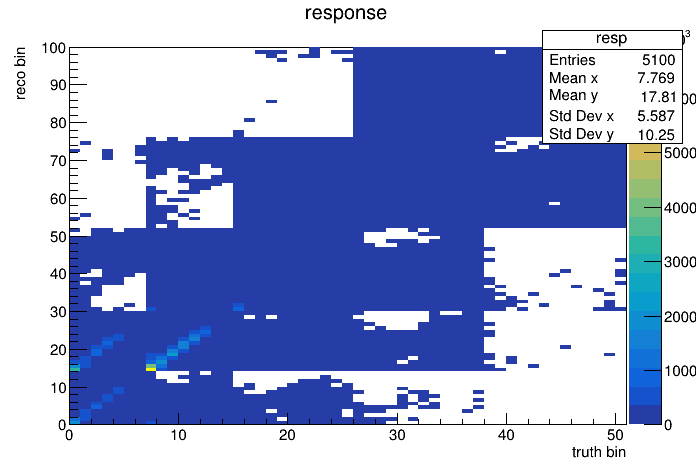

In [ ]:
c = ROOT.TCanvas()
h_resp.Draw('colz')
c.Draw()

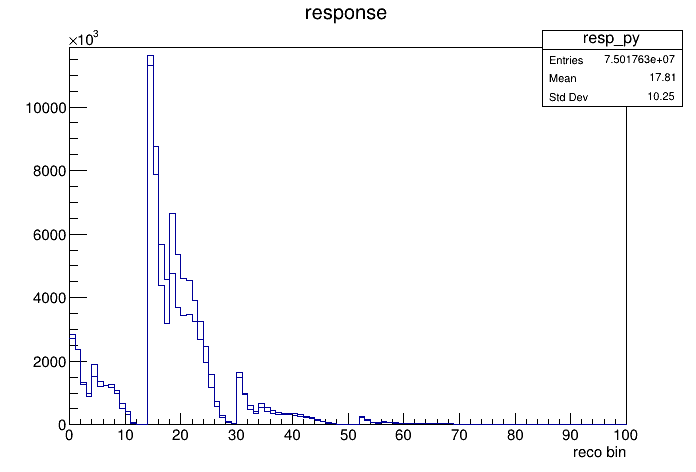

In [ ]:
c = ROOT.TCanvas()
projy = h_resp.ProjectionY()
projy.Draw()
h_meas.Draw('same')
c.Draw()

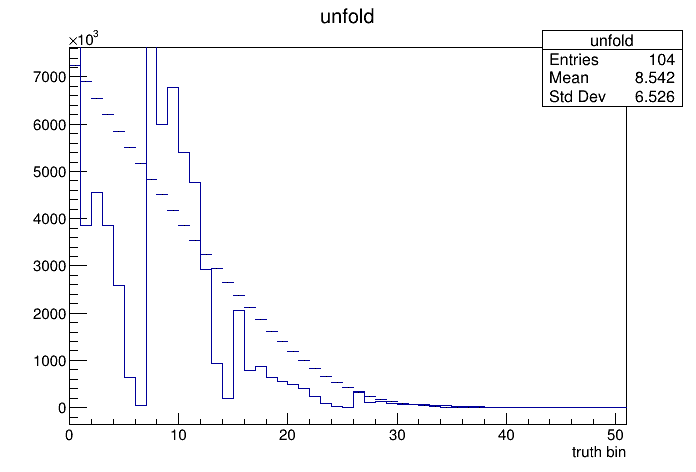

In [ ]:
c = ROOT.TCanvas()
projx = h_resp.ProjectionX()

h_unfold.Draw('same')
projx.Draw('same')
c.Draw()

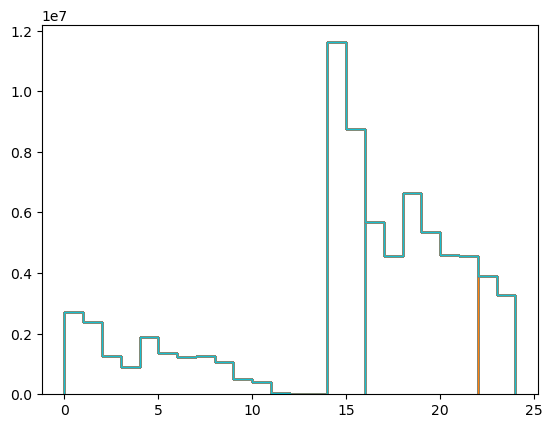

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# helper to move a TH1 into numpy arrays
def th1_to_arrays(h):
    nb = h.GetNbinsX()
    x  = np.arange(1, nb + 1)                           # bin numbers
    y  = np.array([h.GetBinContent(int(i)) for i in x])
    ye = np.array([h.GetBinError(int(i))   for i in x])
    return x, y, ye

x_meas, y_meas, ye_meas = th1_to_arrays(h_meas)
x_unf , y_unf , ye_unf  = th1_to_arrays(h_unfold)

for mass_edges in reco_mass_edges_by_pt:
    n_bin = len(mass_edges) - 1
    for i in range(n_bin):
        plt.stairs(y_meas[0:n_bin])

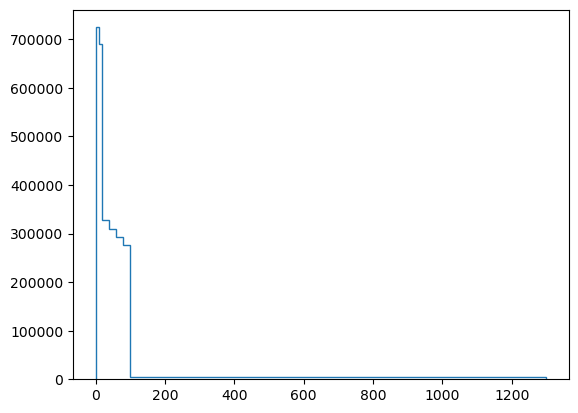

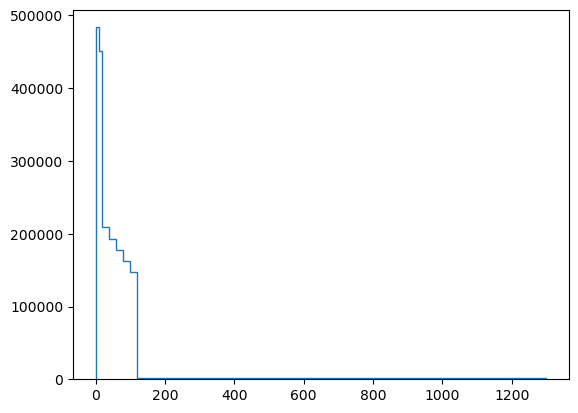

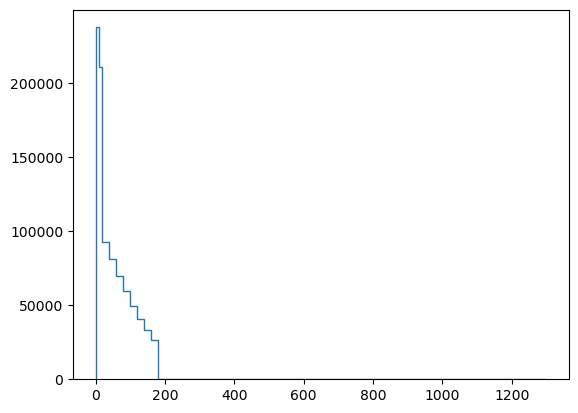

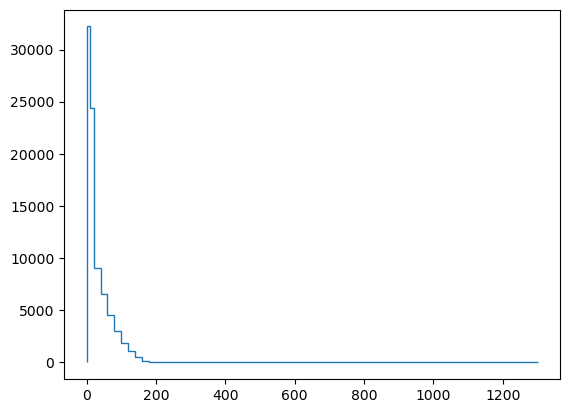

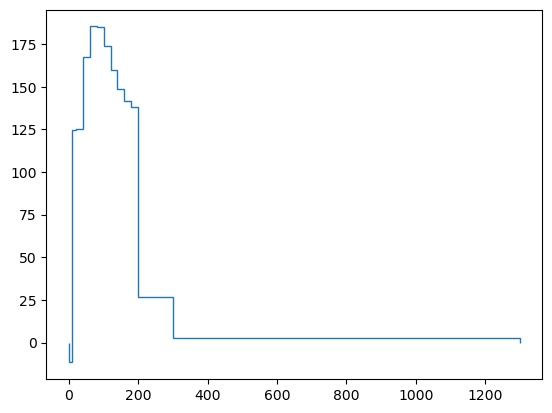

In [ ]:
unfolded_pt_binned = unflatten_gen_by_pt(y_unf, gen_mass_edges_by_pt)

for i in range(len(pt_edges)-1):
    bin_widths = np.diff(gen_mass_edges_by_pt[i])
    plt.stairs(unfolded_pt_binned[i]/bin_widths, gen_mass_edges_by_pt[i] )
    plt.show()

In [12]:
array_list

NameError: name 'array_list' is not defined